# Equivalent widths and radial velocities 
La idea de este notebook es calcular los anchos equivalentes de los espectros de 4most para un sólo objeto, en principio en la línea H-alpha y luego extenderla a otras junto con las velocidades radiales.

In [17]:
import os
import glob
import numpy as np
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt 
from specutils import Spectrum 
from specutils import SpectralRegion
from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline
from scipy.interpolate import UnivariateSpline
from astropy.coordinates import SkyCoord
from scipy.ndimage import median_filter
from specutils.analysis import equivalent_width
from scipy.signal import find_peaks, peak_widths
from astropy.visualization import quantity_support

In [18]:
def open_single_spectrum_4MOST(filename):
    """
    Abre un archivo FITS, extrae flujo, longitud de onda y calcula el ruido SNR.
    Retorna un diccionario con los datos. Las variables se pueden extraer con las keys:

    "wavelength" "flux" "err" 
    "snr_global" "snr_g" "snr_b" 
    "exptime" "header": header_0.
    """
    try:
        with fits.open(filename) as hdu:
            dat = hdu[1].data
            header_0 = hdu[0].header
            header_1= hdu[1].header
            # Extracción de variables
            flux = dat['flux'][0]
            wavelength = dat['wave'][0]  
            err = dat['err'][0].astype(np.float64)  #para el nuevo formato    
            exptime= header_0['EXPTIME']
            
            bands = {
            'Blue':  (3700, 5400), 
            'Green': (5300, 7070),
            'Red':   (6900, 9500)}

            
            #good_pixels= err> 8E-18
            #clean_err= err[good_pixels]
            #new_flux= flux[good_pixels]
            #clean_wave= wavelength[good_pixels]
            
            
                        # Generamos las máscaras usando el eje limpio (wavelength)
            idx_blue = (wavelength >= bands['Blue'][0]) & (wavelength <= bands['Blue'][1])
            idx_green = (wavelength > bands['Green'][0]) & (wavelength <= bands['Green'][1])
            idx_red = (wavelength > bands['Red'][0]) & (wavelength <= bands['Red'][1])
            
            
            # Calculamos el SNR aplicando las nuevas máscaras a los flujos e ivar limpios
            #MODIFICAR CON EL ERROR 
            #ivar= 1/(err**2)
            snr_blue = np.nanmedian(flux[idx_blue] /(err[idx_blue]))
            snr_green = np.nanmedian(flux[idx_green] / (err[idx_green]))
            snr_red = np.nanmedian(flux[idx_red] /(err[idx_red]))
             
            # SNR global
            snr_array= flux/err
            snr_global= np.nanmedian(snr_array)


            #noise_norm = noise / np.median(flux)
            return {
                "filename": os.path.basename(filename),
                "wavelength": wavelength,
                "flux": flux,
                "err": err,
                "snr_global": snr_global,
                "snr_r": snr_red,
                "snr_g": snr_green,
                "snr_b": snr_blue,
                "exptime": exptime,
                "header": header_0
            }
            
    except Exception as e:
        print(f"Error procesando {filename}: {e}")
        return None
    
def load_all_spectra_4most(folder_path):
    
    """
    Abre un archivo FITS, extrae flujo, longitud de onda y calcula el ruido.
    Retorna un diccionario con los datos.
    Ejemplo de uso
    base_de_datos = load_all_spectra(carpeta_datos)
    y para acceder al primer espectro cargado:
    primer_espectro = base_de_datos[0]
    """
    search_pattern = os.path.join(folder_path, "*.fits") 
    
    #Lista con todos los archivos que coincidan con *.fits
    fits_files = glob.glob(search_pattern)
    
    print(f"Se encontraron {len(fits_files)} archivos espectrales.")
    
    spectra_database = []
    
    for file in fits_files:
        data = open_single_spectrum_4MOST(file)
        if data is not None:
            spectra_database.append(data)
            
    return spectra_database

In [19]:
hdu0= fits.open('CVs/qmost_08440009+0239192_1312603110211412333_LJ11_20260311.fits')
hdu1= fits.open('CVs/qmost_08440009+0239192_1312603110241412333_LJ11_20260311.fits')
hdu2= fits.open('CVs/qmost_08440009+0239192_1312603110271412333_LJ11_20260311.fits')
hdu3= fits.open('CVs/qmost_08440009+0239192_1332603110271412333_LJ13_20260311.fits')   #suma de los 3 anteriores

#desempaquetamos y les damos las unidades a los ejes 
lamb0= hdu0[1].data['wave'][0] *u.AA
flux0= hdu0[1].data['flux'][0] *u.Unit('erg cm-2 s-1 AA-1')

lamb1= hdu1[1].data['wave'][0] *u.AA
flux1= hdu1[1].data['flux'][0] *u.Unit('erg cm-2 s-1 AA-1')

lamb2= hdu2[1].data['wave'][0] *u.AA
flux2= hdu2[1].data['flux'][0] *u.Unit('erg cm-2 s-1 AA-1')

lamb3= hdu3[1].data['wave'][0] *u.AA
flux3= hdu3[1].data['flux'][0] *u.Unit('erg cm-2 s-1 AA-1')

#los convertimos en objetos de la clase Spectrum 
spec0= Spectrum(spectral_axis=lamb0, flux=flux0)
spec1= Spectrum(spectral_axis=lamb1, flux=flux1)
spec2= Spectrum(spectral_axis=lamb2, flux=flux2)
spec3= Spectrum(spectral_axis=lamb3, flux=flux3) 

In [20]:
# exposure times solo por tenerlos 
et0= hdu0[0].header['TEXPTIME']
et1= hdu1[0].header['TEXPTIME']
et2= hdu2[0].header['TEXPTIME']
et3= hdu3[0].header['TEXPTIME']

print('Exposure times: ', et0, et1, et2, et3)

Exposure times:  1200.0 1200.0 1200.0 3600.0


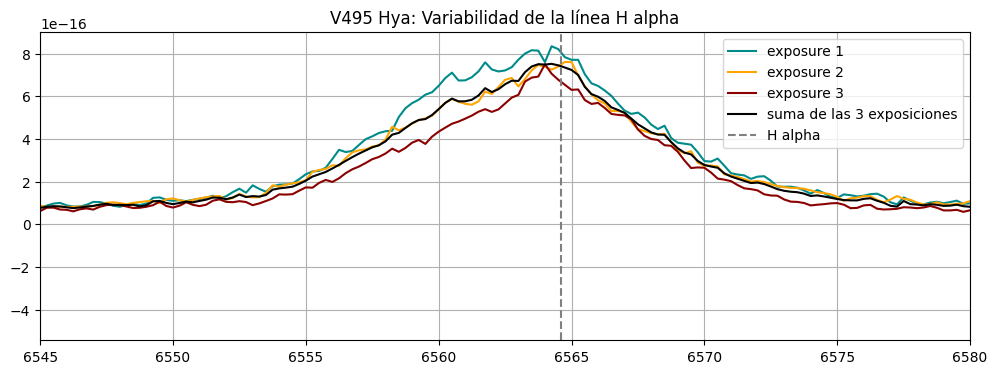

In [21]:
### %matplotlib qt5
plt.figure(figsize=(12,4))    #graficamos en torno a h alpha para ver la variabilidad de la línea
plt.title('V495 Hya: Variabilidad de la línea H alpha')
plt.plot(spec0.spectral_axis, spec0.flux, label='exposure 1',color='darkcyan')
plt.plot(spec1.spectral_axis, spec1.flux, label='exposure 2',color='orange')
plt.plot(spec2.spectral_axis, spec2.flux, label='exposure 3', color='darkred')
plt.plot(spec3.spectral_axis, spec3.flux, label='suma de las 3 exposiciones', color='black')
plt.axvline(6564.614, color='grey', linestyle='--', label='H alpha')  #línea vertical para marcar la posición de h alpha
plt.xlim(6545,6580)
plt.legend()
plt.grid('on')

# 6564.614, guiandonos con SDSS y 6564.5377 la posición que tenemos nosotros (en lab)

#### Enmascarar líneas y normalizar

In [22]:
def mask_lines(espectro, sigma=4, plot=False):
    
    """
    Procesa el espectro en 3 bandas independientes (Blue, Green, Red) para 
    calcular estadísticas locales y enmascarar líneas de emisión y absorción.
    OUTPUTS:
    continuos_bandas, global_mask, found_lines_data
    """
    # Desempaquetar datos globales
    wavelength= espectro['wavelength']
    flux= espectro['flux']
    filename= espectro.get('filename', 'Espectro') # si no encuentra el filename nos devuelve sólo 'Espectro'
    #pseudo normalizamos el flujo para que sea más fácil todo
    #flux= flux/np.median(flux)
    
    # Diccionario con las bandas
    bands = {
    'Blue':  (3700, 5400), 
    'Green': (5300, 7070),
    'Red':   (6900, 9500)}
    
    # Diccionario con las líneas 
    lines = {
    # Serie de Balmer 
    'H_alpha': 6564.5377 * u.AA,  'H_beta': 4862.721 * u.AA,   'H_gamma': 4340.462 * u.AA,
    'H_delta': 4101.74 * u.AA,    'H_epsilon': 3970.072 * u.AA, 'H_zeta': 3889.049 * u.AA,
    'H_eta': 3835.384 * u.AA,     'H_break': 3646.0 * u.AA,

    # He II 
    'HeII_a': 4686.992 * u.AA,    'HeII_b': 5413.024 * u.AA,  
    'HeII_d': 4542.863 * u.AA,    'HeII_f': 4201.014 * u.AA,
    'HeII_h': 4026.738 * u.AA,    'HeII_i': 1640.41 * u.AA,
    'HeII_j': 1215.13 * u.AA,     'HeII_k': 1085.12 * u.AA,     'HeII_l': 1025.44 * u.AA,

    # He I
    'HeI_a': 3706.054 * u.AA,     'HeI_b': 3733.921 * u.AA,     'HeI_c': 3820.694 * u.AA,
    'HeI_d': 3868.596 * u.AA,     'HeI_f': 3965.852 * u.AA,
    'HeI_g': 4010.404 * u.AA,     'HeI_h': 4025.107 * u.AA,     'HeI_i': 4027.338 * u.AA,
    'HeI_j': 4121.982 * u.AA,     'HeI_k': 4144.929 * u.AA,     'HeI_l': 4170.146 * u.AA,
    'HeI_m': 4389.163 * u.AA,     'HeI_n': 4438.795 * u.AA,     'HeI_o': 4472.755 * u.AA,
    'HeI_p': 4714.519 * u.AA,     'HeI_q': 4923.304 * u.AA,     'HeI_r': 5017.079 * u.AA,
    'HeI_s': 5049.147 * u.AA,     'HeI_t': 5877.329 * u.AA,     'HeI_u': 6679.994 * u.AA,
    'HeI_v': 7067.124 * u.AA,     'HeI_w': 7283.357 * u.AA,     'HeI_x': 3188.622 * u.AA,
    'HeI_y': 2945.961 * u.AA,
    
    #lineas que están pero aún no sé de que son
    '5175': 5175 * u.AA, '5578': 5578 * u.AA, '6310': 6310 * u.AA ,    
    # #lineas telúricas 
    'Sky_OH_7316': 7316.3 * u.AA, 'Sky_OH_7341': 7340.9 * u.AA,'Sky_OH_7369': 7369.3 * u.AA,
    'Sky_OH_7821': 7821.5 * u.AA,'Sky_OH_7853': 7853.4 * u.AA,'Sky_OH_7914': 7913.7 * u.AA,
    'Sky_OH_8344': 8344.6 * u.AA,'Sky_OH_8399': 8399.1 * u.AA,'Sky_OH_8430': 8430.2 * u.AA,
    'Sky_OH_8827': 8827.1 * u.AA,'Sky_OH_8920': 8919.7 * u.AA,'Sky_OH_9318': 9318.0 * u.AA,
    'Sky_OH_9376': 9376.0 * u.AA}
    
    #Comentar respecto a la resolución del espectro y las líneas muy cercanas entre sí (<1AA)
    # las que eliminé es pq chocan con H_zeta, H_delta, H_beta, H_gamma respectivamente
    #'HeI_e': 3889.752 * u.AA, 'HeII_g': 4101.197 * u.AA, 'HeII_c': 4860.677 * u.AA, 'HeII_e': 4339.89 * u.AA
    # Inicializamos máscara global (todo True al principio)
    
    global_mask = np.ones(len(wavelength), dtype=bool)
    
    # Estructuras para guardar resultados
    found_lines_data = []  # tuplas (Nombre, Lambda, FWHM)
    continuos_bandas = {} # Aquí guardaremos los 3 continuos separados
    
     # BUCLE PRINCIPAL POR BANDAS
    for band_name, (w_min, w_max) in bands.items():
        # 1 Recortamos el espectro para trabajar por bandas
        idx_band = (wavelength >= w_min) & (wavelength <= w_max)
        
        # Si la banda está vacía (por recorte del espectro), saltamos
        if np.sum(idx_band) == 0:
            continue

        wave_local = wavelength[idx_band]
        flux_local = flux[idx_band]
        
        # 2 Limpieza y cálculo de ruido LOCAL y SNR
        flux_clean = flux_local.astype(float)
        continuum_rough = median_filter(flux_clean, size=101)
        flattened = flux_local - continuum_rough
        flattened_inv = -flattened
        
        # usamos MAD porque es menos sensible al ruido (lo típico sería np.std --(ivar**-2)-- derechamente pero trae más ruido)
        mad = np.median(np.abs(flattened - np.median(flattened)))
        if mad == 0: mad = 1e-5        
        noise_level = mad * 1.4826
        
        # 3 Detección Automática (Find Peaks)
        # Usamos prominence basada en el ruido calculado
        peaks, properties = find_peaks(flattened, prominence=sigma*noise_level, width=2) 
        abs_peaks, abs_properties= find_peaks(flattened_inv, prominence= 5*noise_level, width=2)
        
        
        abs_widths,_,_,_ = peak_widths(flattened_inv, abs_peaks, rel_height=0.5,
                                            prominence_data=(abs_properties['prominences'], 
                                                            abs_properties['left_bases'], 
                                                            abs_properties['right_bases']))  #para absorción
        
        widths_fwhm, _, _, _ = peak_widths(flattened, peaks, rel_height=0.5,
                                            prominence_data=(properties['prominences'], 
                                                            properties['left_bases'], 
                                                            properties['right_bases']))   # para emisión 
        
        mask = np.ones(len(wavelength), dtype=bool)
        treshold_match = 12 

        found_lines_names_local = set()
        c_km_s = 299792.458  # velocidad de la luz en km/s
        if band_name == 'Blue':
            v_mask_limit= 800.0
        else:
            v_mask_limit = 1000.0 #  +- 1000 km/s alrededor de cada línea
        #enmascaramos las líneas de absorción
        for p_idx, w_px in zip(abs_peaks, abs_widths):
            if flattened[p_idx] > 0: continue # Si el pico en el espectro original apunta hacia arriba, lo ignoramos
            obs_w = wave_local[p_idx]    
                    
            # Dispersión local para pasar px -> Angstroms
            if p_idx < len(wave_local)-1:
                disp = wave_local[p_idx + 1] - wave_local[p_idx]
            else:
                disp = wave_local[p_idx] - wave_local[p_idx-1]
                    
            fwhm_abs_ang = w_px * disp
            fwhm_abs_vel=  c_km_s * (fwhm_abs_ang / obs_w)  

            #half_width_ang_abs = (fwhm_abs_vel * obs_w) / c_km_s
            half_width_ang_abs = (v_mask_limit * obs_w) / c_km_s
            found_match = False
            matched_name = ""
                    
            for name, line in lines.items():
                if abs(obs_w - line.value) < treshold_match:
                    found_match = True
                    matched_name = name
                    break

                
            if found_match:
            # Aplicamos la máscara global usando el ancho que calculamos arriba
                mask_width_abs= half_width_ang_abs *2.2 #para asegurarnos de incluir las alas
                #mask_width_abs= fwhm_abs_ang *2.5
                bad_region = (wavelength > obs_w - mask_width_abs) & (wavelength < obs_w + mask_width_abs)
                global_mask[bad_region] = False
                        
                found_lines_names_local.add(matched_name)   
                found_lines_data.append({
                    'name': matched_name, 
                    'wave': obs_w, 
                    'fwhm_ang': fwhm_abs_ang,
                    'type': 'absorption'
                        })
        
        #ahora las de emisión
        for peak_i, w_fwhm_px  in zip(peaks, widths_fwhm):
            obs_wave = wave_local[peak_i]
         
            # pasamos FWHM a velocidad usando la dispersión local para pasar de pixeles a angstroms
            if peak_i < len(wave_local)-1:
                dispersion = wave_local[peak_i + 1] - wave_local[peak_i]
            else:
                dispersion = wave_local[peak_i] - wave_local[peak_i-1]
            
            fwhm_ang = w_fwhm_px * dispersion
            fwhm_vel = c_km_s * (fwhm_ang / obs_wave)
            
            # calculamos el ancho de la máscara para la longitud de onda donde está la línea
            half_width_ang = (v_mask_limit * obs_wave) / c_km_s
            #half_width_ang = (fwhm_vel * obs_wave) / c_km_s
                
            found_match = False
            matched_name = ""
                
            for name, line in lines.items():
                if name in found_lines_names_local: continue
                if abs(obs_wave - line.value) < treshold_match:
                    found_match = True
                    matched_name = name
                    break

                
            if found_match:
                # Aplicamos la máscara global usando el ancho que calculamos arriba
                mask_width= half_width_ang*2.2 #para asegurarnos de incluir las alas
                #mask_width= fwhm_ang *2
                bad_region = (wavelength > obs_wave - mask_width) & (wavelength < obs_wave + mask_width)
                global_mask[bad_region] = False
                
                found_lines_names_local.add(matched_name)   
                found_lines_data.append({
                    'name': matched_name, 
                    'wave': obs_wave, 
                    'fwhm_ang': fwhm_ang,
                    'fwhm_vel': fwhm_vel, 
                    'type': 'emission'})

        # 4. Modo Rescate (Solo para líneas que caen en esta banda)
        rescued_count = 0
        for name, line_val in lines.items():
            
            # Si ya la encontramos seguimos de largo
            if name in found_lines_names_local: continue
            
            center_val = line_val.value
            
            # Solo intentamos rescatar si la línea pertenece a esta banda
            if not (w_min <= center_val <= w_max): continue
            
            # Ventana de búsqueda local
            window_mask = (wave_local > center_val - 15) & (wave_local < center_val + 15)
            
            if np.sum(window_mask) > 0:
                local_flux_window = flattened[window_mask]
                
                if len(local_flux_window) == 0: continue
                
                local_max_idx = np.argmax(local_flux_window)
                max_val = local_flux_window[local_max_idx]
                
                wave_window = wave_local[window_mask]
                peak_wave_rescue = wave_window[local_max_idx]
                
                # comprobamos si no está registrada y si es así enmascaramos
                ya_existe = any(abs(peak_wave_rescue - d['wave']) < 10.0 for d in found_lines_data)
                
                if not ya_existe and max_val > 2 * noise_level:

                    v_rescue = 1800.0 # km/s (un valor para cubrir alas)
                    rescue_width = (v_rescue * center_val) / c_km_s 
                    bad_region_rescue = (wavelength > peak_wave_rescue - rescue_width) & \
                                        (wavelength < peak_wave_rescue + rescue_width)
                    global_mask[bad_region_rescue] = False
                    
                    rescued_count += 1
                    found_lines_data.append({'name': name, 'wave': peak_wave_rescue, 'fwhm': np.nan, 'band': band_name, 'type': 'rescued'})

        # 5. Guardar el Continuo de esta Banda
        # Recortamos flux_local usando la máscara global (intersección con la banda)
        mask_local = global_mask[idx_band]
        
        # Guardamos tupla (Wavelength, Flux) limpios
        continuos_bandas[band_name] = (wave_local[mask_local], flux_local[mask_local])
        
       # print(f"  > {band_name}: Ruido={noise_level:.2f} | Líneas Auto={len(found_lines_names_local)} | Rescatadas={rescued_count}")


    # VISUALIZACIÓN
    if plot:
        #creamos el array maestro con huecos (NaNs)
        gaps_continuum = flux.copy()
        gaps_continuum[~global_mask] = np.nan 
        
        plt.figure(figsize=(12, 5))
        plt.title(f"{filename} - Análisis Multibanda")
        plt.plot(wavelength, flux, color='grey', alpha=0.6, label='Original')
        
        #  Continuos por banda con gaps
        colors = {'Blue': 'blue', 'Green': 'green', 'Red': 'red'}
        
        #  Iteramos sobre bands (los límites) para recortar el array con NaNs
        for b_name, (w_min, w_max) in bands.items():
            
            # Buscamos los índices de esta banda en el array global
            idx_band = (wavelength >= w_min) & (wavelength <= w_max)
            
            # Recortamos el array que tiene nans. 
            plt.plot(wavelength[idx_band], gaps_continuum[idx_band], 
                    color=colors[b_name], lw=1.5, alpha=0.8, label=f'Banda {b_name}')
            
        # graficamos el continuo global desplazado 
        plt.plot(wavelength, gaps_continuum-1E-16 , color='black', lw=1, alpha=0.8, label='Global (Offset -20)')

        plt.xlabel(r'Wavelength $\AA$')
        plt.ylabel(r'Flux ($10^{-17} ergs\,cm^{-2}\,s^{-1}\,\AA^{-1}$)')
        plt.legend(loc='upper right')
        #plt.axvline(5175)
        #plt.axvline(5275)    #lineas presentes en el espectro [1] (en varios realmente)
        #plt.axvline(6564)
        plt.grid('on')
        plt.tight_layout()
        plt.show()
        
    return continuos_bandas, global_mask, found_lines_data # luego añadirS/N 

db_4most= load_all_spectra_4most('CVs/')

n= 0
spect_n_4most= db_4most[n]
continuos, mask, lines= mask_lines(spect_n_4most,plot=False)


Se encontraron 10 archivos espectrales.


C:\Users\paisa\AppData\Local\Temp\ipykernel_26988\3393920557.py:44: RuntimeWarning: invalid value encountered in divide
  snr_red = np.nanmedian(flux[idx_red] /(err[idx_red]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_26988\3393920557.py:47: RuntimeWarning: invalid value encountered in divide
  snr_array= flux/err


C:\Users\paisa\AppData\Local\Temp\ipykernel_26988\4178467974.py:13: RuntimeWarning: divide by zero encountered in divide
  weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR


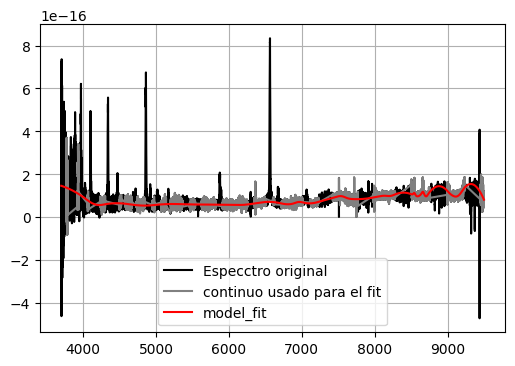

In [23]:
#ahora que tenemos las lineas enmascaradas podemos fitear el continuo con splines o polinomios
# y luego dividir el espectro original por ese continuo para normalizarlo.

n= 0
spect_n_4most= db_4most[n]
continuos, mask, lines= mask_lines(spect_n_4most,plot=False)
cont_0= spect_n_4most['flux'][mask]
wave_0= spect_n_4most['wavelength'][mask]

err_64 = spect_n_4most['err'].astype(np.float64) #subimos la precisión para evitar el runtime warning para valores muy bajitos
err_masked= err_64[mask]
good_pixels= err_masked> 1E-20
weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR



#cont_0_fill = np.interp(spect_n_4most['wavelength'], wave_0, cont_0)  # rellenamos los huecos con interpolación lineal 
#para evitar problemas con el spline

spline_fit= UnivariateSpline(wave_0[good_pixels],cont_0[good_pixels],w=weigths[good_pixels],k=2,s=22000)
flux_model= spline_fit(spect_n_4most['wavelength'])

spec0_norm= spect_n_4most['flux']/ flux_model


plt.figure(figsize=(6,4))    
#plt.plot(spect_n_4most['wavelength'], spec0_norm)
plt.plot(spect_n_4most['wavelength'], spect_n_4most['flux'], color='black', label= 'Especctro original') # type: ignore
plt.plot(wave_0[good_pixels], cont_0[good_pixels], color='grey',label='continuo usado para el fit')
plt.plot(spect_n_4most['wavelength'], flux_model, color='red', label='model_fit')
plt.legend()
plt.grid('on')

#plt.xlim(8980,9000)
#plt.ylim(-5*1E-16,8.5*1E-16)


In [24]:
# Acá creamos la funcción para normalizar utilizando la lógica de arriba (para aplicarlo a todos)
def normalize_spectrum(espectro, mask, plot=False, s=22000):
    """
    Esta función normaliza un espectro dado utilizando un spline ajustado al continuo definido por la máscara
    que se obtiene usando la función mask_lines."""
    
    # Desempaquetar datos globales
    wavelength= espectro['wavelength']
    flux= espectro['flux']
    err_64 = espectro['err'].astype(np.float64) #subimos la precisión para evitar el runtime warning para valores muy bajitos
    err_masked= err_64[mask]
    good_pixels= err_masked> 1E-20
    weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR
    
    cont_masked = flux[mask]
    wave_masked = wavelength[mask]
    
    # Ajustamos un spline al continuo usando solo los píxeles buenos
    spline_fit= UnivariateSpline(wave_masked[good_pixels], cont_masked[good_pixels], w=weigths[good_pixels], k=2, s=s)
    
    # Evaluamos el spline en todas las longitudes de onda para obtener el modelo de continuo
    flux_model= spline_fit(wavelength)
    
    # Normalizamos dividiendo el flujo original por el modelo de continuo
    normalized_flux = flux / flux_model
    
    if plot:
        plt.figure(figsize=(6, 5))
        plt.title(f"{espectro.get('filename', 'Espectro')}")
        plt.plot(wavelength, flux, color='black', label='Espectro Original')
        plt.plot(wave_masked[good_pixels], cont_masked[good_pixels], color='grey', label='Continuo Usado para Fit')
        plt.plot(wavelength, flux_model, color='red', label='Modelo de Continuo (Spline Fit)')
        plt.xlim(wavelength.min()-50, wavelength.max()+50)
        plt.xlabel(r'Wavelength $\AA$')
        plt.ylabel(r'Flux ($10^{-17} ergs\,cm^{-2}\,s^{-1}\,\AA^{-1}$)')
        plt.legend(loc='upper right')
        plt.grid('on')
        plt.tight_layout()
        plt.show()
    
    return normalized_flux, flux_model

C:\Users\paisa\AppData\Local\Temp\ipykernel_26988\69013664.py:13: RuntimeWarning: divide by zero encountered in divide
  weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR


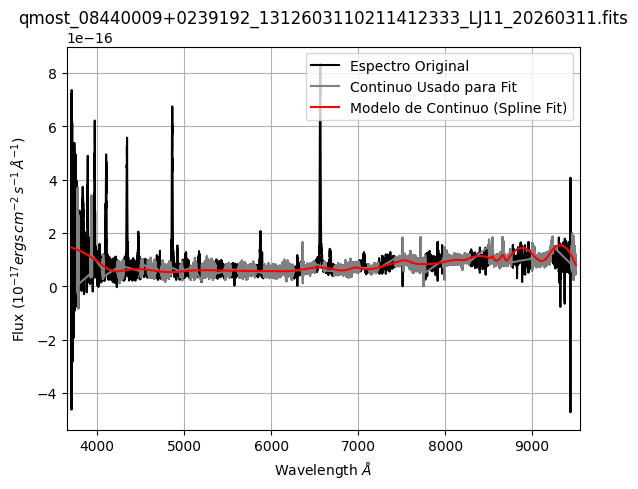

In [25]:
n= 0  #celda para probar la función
spect_n_4most= db_4most[n]
continuos, mask, lines= mask_lines(spect_n_4most,plot=False)
normalized_flux= normalize_spectrum(spect_n_4most, mask, plot=True)

C:\Users\paisa\AppData\Local\Temp\ipykernel_26988\69013664.py:13: RuntimeWarning: divide by zero encountered in divide
  weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR


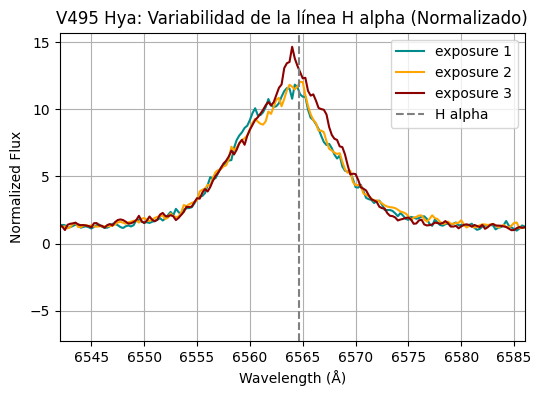

In [26]:
#%matplotlib qt
spec0= db_4most[0]
spec1= db_4most[1]
spec2= db_4most[2]
spec3= db_4most[3]

mask0= mask_lines(spec0, plot=False)[1]
mask1= mask_lines(spec1, plot=False)[1] 
mask2= mask_lines(spec2, plot=False)[1]
mask3= mask_lines(spec3, plot=False)[1]

norm0= normalize_spectrum(spec0, mask0, plot=False)[0]
norm1= normalize_spectrum(spec1, mask1, plot=False)[0]
norm2= normalize_spectrum(spec2, mask2, plot=False)[0]
norm3= normalize_spectrum(spec3, mask3, plot=False)[0]

plt.figure(figsize=(6,4))
plt.title('V495 Hya: Variabilidad de la línea H alpha (Normalizado)')
plt.plot(spec0['wavelength'], norm0, label='exposure 1',color='darkcyan')
plt.plot(spec1['wavelength'], norm1, label='exposure 2',color='orange')
plt.plot(spec2['wavelength'], norm2, label='exposure 3',color='darkred')
#plt.plot(spec3['wavelength'], norm3, label='exposure 4',color='black')
plt.axvline(6564.614, color='grey', linestyle='--', label='H alpha')  #línea vertical para marcar la posición de h alpha
plt.xlabel('Wavelength (Å)')
plt.ylabel('Normalized Flux')
plt.xlim(6542,6586)   # 22 angstroms de lado y lado
plt.grid('on')
plt.legend()
plt.show()

In [27]:
exp0= Spectrum(spectral_axis=spec0['wavelength']*u.AA, flux=norm0 *u.dimensionless_unscaled)
exp1= Spectrum(spectral_axis=spec1['wavelength']*u.AA, flux=norm1 *u.dimensionless_unscaled)
exp2= Spectrum(spectral_axis=spec2['wavelength']*u.AA, flux=norm2 *u.dimensionless_unscaled)
exp3= Spectrum(spectral_axis=spec3['wavelength']*u.AA, flux=norm3 *u.dimensionless_unscaled)

region_halpha = SpectralRegion(6542 * u.AA, 6586 * u.AA)

ew_1 = equivalent_width(exp0, regions=region_halpha, continuum=1 * u.dimensionless_unscaled)
ew_2 = equivalent_width(exp1, regions=region_halpha, continuum=1 * u.dimensionless_unscaled)
ew_3 = equivalent_width(exp2, regions=region_halpha, continuum=1 * u.dimensionless_unscaled)
ew_co = equivalent_width(exp3, regions=region_halpha, continuum=1 * u.dimensionless_unscaled)

# 4. IMPRIMIR RESULTADOS
print(f"EW LJ11 (Expo 1): {ew_1:.6f}")
print(f"EW LJ11 (Expo 2): {ew_2:.6f}")
print(f"EW LJ11 (Expo 3): {ew_3:.6f}")
print(f"EW LJ13 (Co-added): {ew_co:.6f}")

EW LJ11 (Expo 1): -128.034813 Angstrom
EW LJ11 (Expo 2): -130.089003 Angstrom
EW LJ11 (Expo 3): -137.937294 Angstrom
EW LJ13 (Co-added): -126.363571 Angstrom


### Reiteramos el análisis pero ahora para H_beta

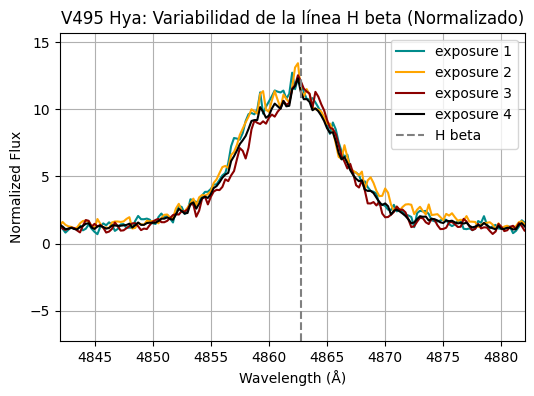

In [28]:
plt.figure(figsize=(6,4))
plt.title('V495 Hya: Variabilidad de la línea H beta (Normalizado)')
plt.plot(spec0['wavelength'], norm0, label='exposure 1',color='darkcyan')
plt.plot(spec1['wavelength'], norm1, label='exposure 2',color='orange')
plt.plot(spec2['wavelength'], norm2, label='exposure 3',color='darkred')
plt.plot(spec3['wavelength'], norm3, label='exposure 4',color='black')
plt.axvline(4862.721, color='grey', linestyle='--', label='H beta')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Normalized Flux')
plt.xlim(4842,4882)
plt.grid('on')
plt.legend()
plt.show()

## Función de EW

In [29]:
def EW(spec, line_center, line_window=25):
    """
    Calcula el Equivalent Width (EW) de una línea dada su posición central y una ventana de análisis.
    """
    mask= mask_lines(spec, plot=False)[1]
    norm= normalize_spectrum(spec, mask, plot=False)[0]
    
    exp= Spectrum(spectral_axis=spec['wavelength']*u.AA, flux=norm *u.dimensionless_unscaled)
    
    region = SpectralRegion((line_center - line_window) * u.AA, (line_center + line_window) * u.AA)
    ew = equivalent_width(exp, regions=region, continuum=1 * u.dimensionless_unscaled)
    return ew, norm

ews_halpha = []
ews_hbeta = []

for  spec in (db_4most):
    ew_halpha = EW(spec, line_center=6564.614)
    ew_hbeta = EW(spec, line_center=4862.721)
    ews_halpha.append(ew_halpha)
    ews_hbeta.append(ew_hbeta)
    #print(f"Espectro {i+1}: EW H alpha = {ew_halpha:.6f}, EW H beta = {ew_hbeta:.6f}")

C:\Users\paisa\AppData\Local\Temp\ipykernel_26988\69013664.py:13: RuntimeWarning: divide by zero encountered in divide
  weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR


In [30]:
ews_halpha[:4]

[(<Quantity -128.7338429 Angstrom>,
  array([3.40876709, 1.96311236, 1.16590087, ..., 1.15473741, 1.06004526,
         1.06175672], shape=(23201,))),
 (<Quantity -131.01476143 Angstrom>,
  array([ 2.62713054, -0.07429742,  1.48009578, ...,  1.20625836,
          1.20297341,  1.0020822 ], shape=(23201,))),
 (<Quantity -139.03973634 Angstrom>,
  array([-0.9960792 , -6.17818779,  1.6126002 , ...,  0.95025503,
          0.87897109,  0.72503399], shape=(23201,))),
 (<Quantity -127.08280824 Angstrom>,
  array([ 2.36533789, -0.42013487,  1.44419148, ...,  0.99947487,
          0.9492394 ,  0.84049132], shape=(23201,)))]

In [31]:
ews_hbeta[:4]

[(<Quantity -127.43794001 Angstrom>,
  array([3.40876709, 1.96311236, 1.16590087, ..., 1.15473741, 1.06004526,
         1.06175672], shape=(23201,))),
 (<Quantity -133.41527017 Angstrom>,
  array([ 2.62713054, -0.07429742,  1.48009578, ...,  1.20625836,
          1.20297341,  1.0020822 ], shape=(23201,))),
 (<Quantity -112.78575102 Angstrom>,
  array([-0.9960792 , -6.17818779,  1.6126002 , ...,  0.95025503,
          0.87897109,  0.72503399], shape=(23201,))),
 (<Quantity -117.98234821 Angstrom>,
  array([ 2.36533789, -0.42013487,  1.44419148, ...,  0.99947487,
          0.9492394 ,  0.84049132], shape=(23201,)))]

TypeError: unsupported format string passed to tuple.__format__

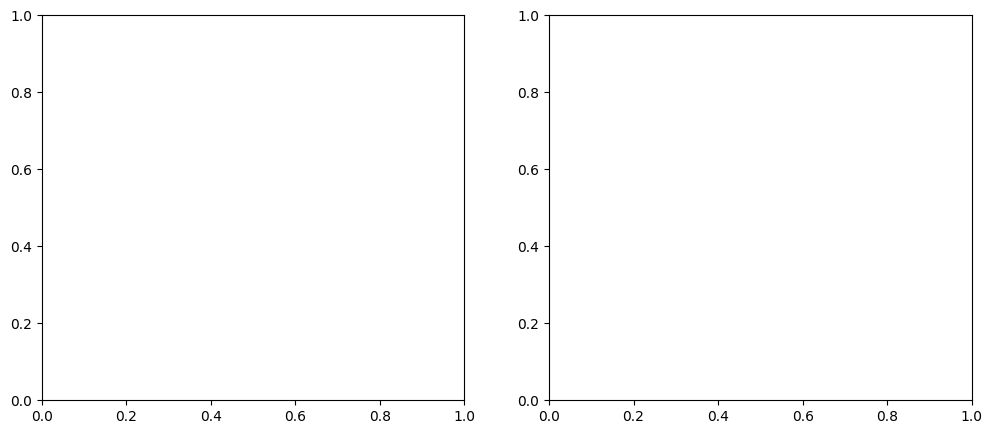

In [32]:
fig, axs= plt.subplots(1,2, figsize=(12,5))

axs[0].plot(spec0['wavelength'],norm0, label= f'EW exp1: {ews_halpha[0]:.3f}', color= 'darkcyan')
axs[0].plot(spec1['wavelength'],norm1, label= f'EW exp2: {ews_halpha[1]:.3f}', color= 'orange' )
axs[0].plot(spec2['wavelength'],norm2, label= f'EW exp3: {ews_halpha[2]:.3f}', color= 'darkred')
#axs[0].plot(spec3['wavelength'],norm3, label= f'EW coadded: {ews_halpha[3]:.3f}', color= 'black')
axs[0].set_xlim(6540,6590)
axs[0].set_title('V495 Hya: Variabilidad de la línea H alpha ')
axs[0].set_xlabel('Wavelength (Å)')
axs[0].set_ylabel('Normalized Flux')
axs[0].axvline(6564.614, color='grey', linestyle='--', label='H alpha')
axs[0].grid('on')
axs[0].legend()

axs[1].plot(spec0['wavelength'],norm0, label= f'EW exp1: {ews_hbeta[0]:.3f}', color= 'darkcyan')
axs[1].plot(spec1['wavelength'],norm1, label= f'EW exp2: {ews_hbeta[1]:.3f}', color= 'orange')
axs[1].plot(spec2['wavelength'],norm2, label= f'EW exp3: {ews_hbeta[2]:.3f}', color= 'darkred')
#axs[1].plot(spec3['wavelength'],norm3, label= f'EW coadded: {ews_hbeta[3]:.3f}', color= 'black')
axs[1].set_xlim(4845,4880)
axs[1].set_title('V495 Hya: Variabilidad de la línea H beta ')
axs[1].set_xlabel('Wavelength (Å)')
axs[1].set_ylabel('Normalized Flux')
axs[1].axvline(4862.721, color='grey', linestyle='--', label='H beta')
axs[1].grid('on')
axs[1].legend()
plt.tight_layout()
plt.show()



C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\69013664.py:13: RuntimeWarning: divide by zero encountered in divide
  weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR


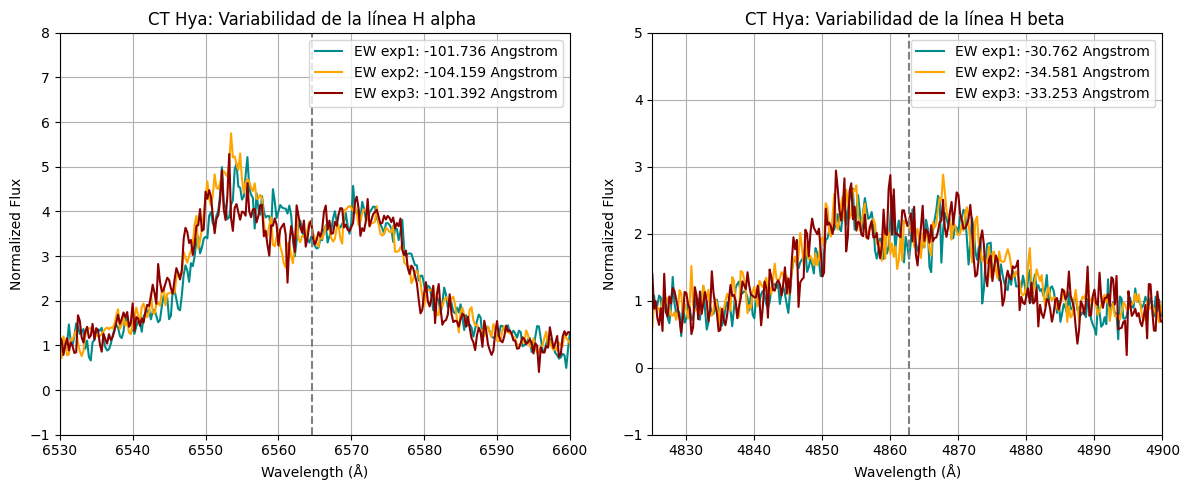

In [ ]:
spec4= db_4most[4]
spec5= db_4most[5]
spec6= db_4most[6]
spec7= db_4most[7]

mask4= mask_lines(spec4, plot=False)[1]
mask5= mask_lines(spec5, plot=False)[1]
mask6= mask_lines(spec6, plot=False)[1]
mask7= mask_lines(spec7, plot=False)[1]

norm4= normalize_spectrum(spec4, mask4, plot=False)[0]
norm5= normalize_spectrum(spec5, mask5, plot=False)[0]
norm6= normalize_spectrum(spec6, mask6, plot=False)[0]
norm7= normalize_spectrum(spec7, mask7, plot=False)[0]

fig, axs= plt.subplots(1,2, figsize=(12,5))

axs[0].plot(spec4['wavelength'],norm4, label= f'EW exp1: {ews_halpha[4]:.3f}', color= 'darkcyan')
axs[0].plot(spec5['wavelength'],norm5, label= f'EW exp2: {ews_halpha[5]:.3f}', color= 'orange' )
axs[0].plot(spec6['wavelength'],norm6, label= f'EW exp3: {ews_halpha[6]:.3f}', color= 'darkred')
#axs[0].plot(spec7['wavelength'],norm7, label= f'EW coadded: {ews_halpha[7]:.3f}', color= 'black')
axs[0].set_xlim(6530,6600)
axs[0].set_title('CT Hya: Variabilidad de la línea H alpha ')
axs[0].set_xlabel('Wavelength (Å)')
axs[0].set_ylabel('Normalized Flux')
axs[0].axvline(6564.614, color='grey', linestyle='--')
axs[0].set_ylim(-1,8)
axs[0].grid('on')
axs[0].legend()

axs[1].plot(spec4['wavelength'],norm4, label= f'EW exp1: {ews_hbeta[4]:.3f}', color= 'darkcyan')
axs[1].plot(spec5['wavelength'],norm5, label= f'EW exp2: {ews_hbeta[5]:.3f}', color= 'orange')
axs[1].plot(spec6['wavelength'],norm6, label= f'EW exp3: {ews_hbeta[6]:.3f}', color= 'darkred')
#axs[1].plot(spec7['wavelength'],norm7, label= f'EW coadded: {ews_hbeta[7]:.3f}', color= 'black')
axs[1].set_xlim(4825,4900)
axs[1].set_title('CT Hya: Variabilidad de la línea H beta ')
axs[1].set_xlabel('Wavelength (Å)')
axs[1].set_ylabel('Normalized Flux')
axs[1].axvline(4862.721, color='grey', linestyle='--')
axs[1].set_ylim(-1,5)
axs[1].grid('on')
axs[1].legend()
plt.tight_layout()
plt.show()


(-3.5e-16, 4.0000000000000004e-16)

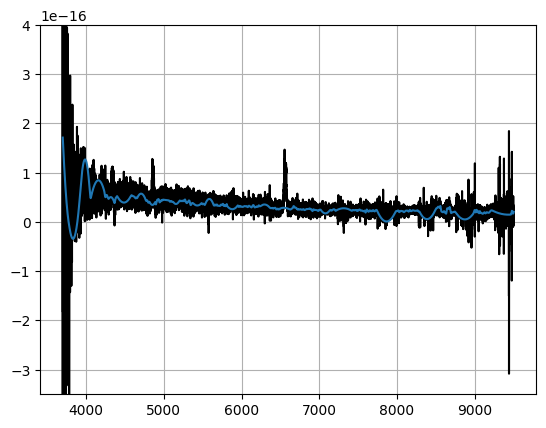

In [ ]:
norm6, model6= normalize_spectrum(spec6, mask6,s=15000)
plt.plot(spec6['wavelength'], spec6['flux'], color='black')
plt.grid('on')
plt.plot(spec6['wavelength'], model6)
plt.ylim(-0.35*1E-15,0.4*1E-15)

# Radial Velocities

### H_alpha

C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\69013664.py:13: RuntimeWarning: divide by zero encountered in divide
  weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR


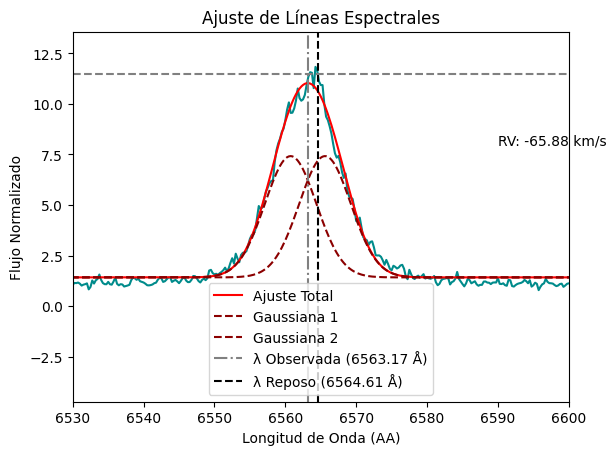

Velocidad Radial estimada: -65.88 km/s


In [ ]:
# para ajustar las gaussianas alrededor de las líneas vamoa a usar curve_fit de scipy.optimize
from scipy.optimize import curve_fit
import numpy as np
from astropy.modeling import models
from scipy.optimize import curve_fit
from specutils.fitting import fit_lines
import astropy.constants as const

c= const.c.to('km/s').value
h_alpha= 6564.614

norm= normalize_spectrum(spec0, mask, plot=False)[0]
region_ajuste= SpectralRegion(6542 * u.AA, 6586 * u.AA)   #region de h_alpha

continuo= models.Const1D(amplitude=1.0) #la parte del continuo
gaussiana1= models.Gaussian1D(amplitude=10, mean=6558 * u.AA, stddev=5 * u.AA)
gaussiana2= models.Gaussian1D(amplitude=10, mean=6566 * u.AA, stddev=5 * u.AA)


#le damos bounds para que tomen la forma que quiero
gaussiana1.amplitude.bounds= (6,12) 
gaussiana2.amplitude.bounds= (6,12)


modelo_base= continuo + gaussiana1 + gaussiana2
modelo_ajustado= fit_lines(exp0, model= modelo_base, window=region_ajuste)

mu_1= modelo_ajustado[1].mean.value
mu_2= modelo_ajustado[2].mean.value

lambda_obs= (mu_1 + mu_2) / 2
rv= c * (lambda_obs - h_alpha) / h_alpha


flux_ajustado = modelo_ajustado(exp0.spectral_axis).value
nivel_continuo = modelo_ajustado[0].amplitude.value
campana_1= (modelo_ajustado[1](exp0.spectral_axis) + nivel_continuo).value
campana_2= (modelo_ajustado[2](exp0.spectral_axis) + nivel_continuo).value

plt.plot(spec0['wavelength'], norm0, color='darkcyan')

plt.plot(spec0['wavelength'], flux_ajustado, label='Ajuste Total', color='red')

plt.plot(spec0['wavelength'], campana_1, label='Gaussiana 1', color='darkred', linestyle='--')
plt.plot(spec0['wavelength'], campana_2, label='Gaussiana 2', color='darkred', linestyle='--')
plt.axvline(lambda_obs, color='grey', linestyle='-.', label=f'λ Observada ({lambda_obs:.2f} Å)')
plt.axvline(h_alpha, color='black', linestyle='--', label=f'λ Reposo ({h_alpha:.2f} Å)')


plt.xlim(6530, 6600)
plt.xlabel('Longitud de Onda (AA)')
plt.ylabel('Flujo Normalizado')
plt.axhline(11.5, color='grey', linestyle='--')
plt.text(6590,8, f'RV: {rv:.2f} km/s', fontsize=10, color='black')
plt.title('Ajuste de Líneas Espectrales')
plt.legend()
plt.show()
print(f"Velocidad Radial estimada: {rv:.2f} km/s")


In [ ]:
def ajuste_RV_Halpha(spec,bounds,amplitude, steddev=5,plot=False):
    """
    Esta función ajusta dos gaussianas a la línea H alpha para estimar la velocidad radial (RV) de la fuente.
    Se pueden ajustar los bounds y amplitudes de las gaussianas para mejorar el ajuste.
    Parámetros:
    - spec: espectro a ajustar
    - bounds: los límites para la amplitud del ajuste 
    - amplitude: initial guess de la ampplitud de las gaussianas
    - steddev: desviación estándar inicial para las gaussianas (en Angstroms) para determinar el ancho
    """
    c= const.c.to('km/s').value
    h_alpha= 6564.614
    
    mask= mask_lines(spec, plot=False)[1]
    norm0= normalize_spectrum(spec, mask, plot=False)[0]
    exp0= Spectrum(spectral_axis=spec['wavelength']*u.AA, flux=norm0 *u.dimensionless_unscaled)
    
    region_ajuste= SpectralRegion(6542 * u.AA, 6586 * u.AA)   #region de h_alpha 
    #El ajuste cambia si hagoi esta ventana más ancha o angosta
    
    
    

    continuo= models.Const1D(amplitude=1.0) #la parte del continuo
    gaussiana1= models.Gaussian1D(amplitude=amplitude[0], mean=6559.8 * u.AA, stddev=steddev * u.AA)
    gaussiana2= models.Gaussian1D(amplitude=amplitude[1], mean=6565.8 * u.AA, stddev=steddev * u.AA)

    #le damos bounds para que tomen la forma que quiero
    gaussiana1.amplitude.bounds= bounds[0] 
    gaussiana2.amplitude.bounds= bounds[1]
    
    
    gaussiana1.mean.bounds = (6540 * u.AA, 6560.8 * u.AA)
    gaussiana2.mean.bounds = (6564.8 * u.AA, 6580 * u.AA)

    modelo_base= continuo + gaussiana1 + gaussiana2
    modelo_ajustado= fit_lines(exp0, model= modelo_base, window=region_ajuste)
    

    mu_1= modelo_ajustado[1].mean.value
    mu_2= modelo_ajustado[2].mean.value

    lambda_obs= (mu_1 + mu_2) / 2
    rv= c * (lambda_obs - h_alpha) / h_alpha

    flux_ajustado = modelo_ajustado(exp0.spectral_axis).value
    nivel_continuo = modelo_ajustado[0].amplitude.value
    campana_1= (modelo_ajustado[1](exp0.spectral_axis) + nivel_continuo).value
    campana_2= (modelo_ajustado[2](exp0.spectral_axis) + nivel_continuo).value
    if plot:
        plt.plot(spec['wavelength'], norm0, color='darkcyan')

        plt.plot(spec['wavelength'], flux_ajustado, label='Ajuste Total', color='red')

        plt.plot(spec['wavelength'], campana_1, label='Gaussiana 1', color='darkred', linestyle='--')
        plt.plot(spec['wavelength'], campana_2, label='Gaussiana 2', color='darkred', linestyle='--')
        plt.axvline(lambda_obs, color='grey', linestyle='-.', label=f'λ Observada ({lambda_obs:.2f} Å)')
        plt.axvline(h_alpha, color='black', linestyle='--', label=f'λ Reposo ({h_alpha:.2f} Å)')

        plt.xlim(6530, 6600)
        plt.xlabel('Longitud de Onda (AA)')
        plt.ylabel('Flujo Normalizado')
       # plt.axhline(11.5, color='grey', linestyle='--')
        plt.text(6590,8, f'RV: {rv:.2f} km/s', fontsize=10, color='black')
        plt.title('Ajuste de Líneas Espectrales')
        plt.legend()
        plt.show()
        print(f"Velocidad Radial estimada: {rv:.2f} km/s")
    return rv, lambda_obs
        
        

C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\69013664.py:13: RuntimeWarning: divide by zero encountered in divide
  weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR


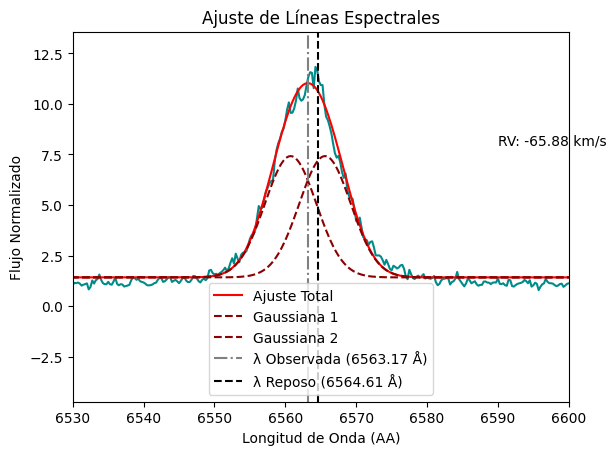

Velocidad Radial estimada: -65.88 km/s


In [ ]:
rv_exp1= ajuste_RV_Halpha(spec0, bounds=[(6,15),(6,15)], amplitude=[11.5,11.5], steddev=5,plot=True)

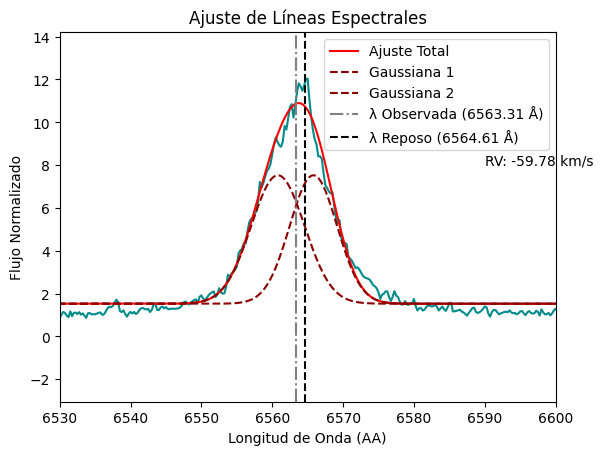

Velocidad Radial estimada: -59.78 km/s


In [ ]:
rv_exp1= ajuste_RV_Halpha(spec1, bounds=[(6,15),(6,15)], amplitude=[11.5,11.5], steddev=5,plot=True)

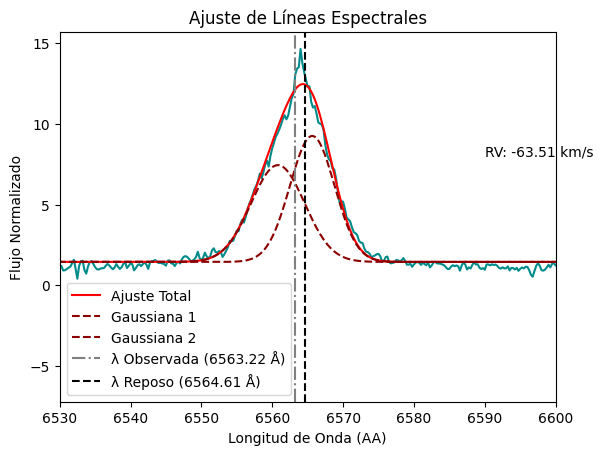

Velocidad Radial estimada: -63.51 km/s


In [ ]:
rv_exp2= ajuste_RV_Halpha(spec2, bounds=[(6,15),(6,15)], amplitude=[11.5,11.5], steddev=5,plot=True) #este tiene detalle

In [ ]:
#%matplotlib qt
rv_V495_Hya= []
rv_exp0= ajuste_RV_Halpha(spec0, bounds=[(6,11.5),(6,11.5)], amplitude=[11.5,11.5], steddev=5,plot=False)
rv_exp1= ajuste_RV_Halpha(spec1, bounds=[(6,11.5),(6,11.5)], amplitude=[11.5,11.5], steddev=5,plot=False)
rv_exp2= ajuste_RV_Halpha(spec2, bounds=[(6,11.5),(6,11.5)], amplitude=[11.5,11.5], steddev=5,plot=False)
rv_V495_Hya.append(rv_exp0)
rv_V495_Hya.append(rv_exp1)
rv_V495_Hya.append(rv_exp2)

C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\69013664.py:13: RuntimeWarning: divide by zero encountered in divide
  weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR


In [ ]:
import pandas as pd
rvs_V495_Hya=pd.DataFrame({'RVs_V495_Hya': [rv_V495_Hya[0][0], rv_V495_Hya[1][0], rv_V495_Hya[2][0]]})
rvs_V495_Hya['lambda_obs']= [rv_V495_Hya[0][1], rv_V495_Hya[1][1], rv_V495_Hya[2][1]]
rvs_V495_Hya

,RVs_V495_Hya,lambda_obs
0,-65.876354,6563.171493
1,-59.775823,6563.305077
2,-63.508874,6563.223334


C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\69013664.py:13: RuntimeWarning: divide by zero encountered in divide
  weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR


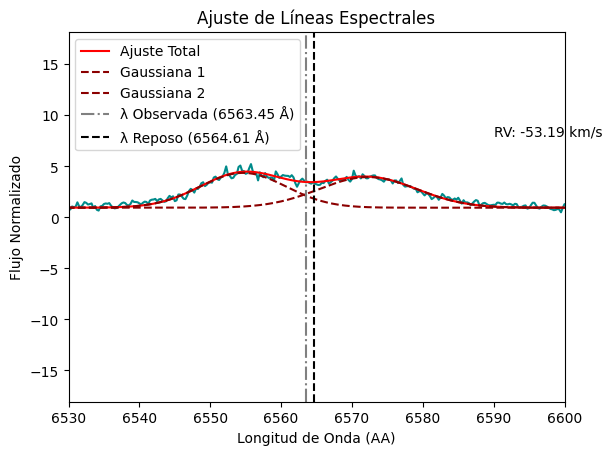

Velocidad Radial estimada: -53.19 km/s


In [ ]:
rv_CT__Hya1= ajuste_RV_Halpha(spec4, bounds=[(3,5),(3,5)], amplitude=[4,4], steddev=5,plot=True)

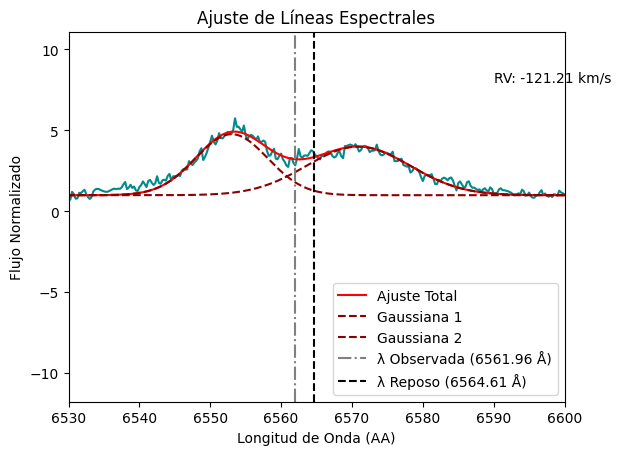

Velocidad Radial estimada: -121.21 km/s


In [ ]:
rv_CT__Hya2= ajuste_RV_Halpha(spec5, bounds=[(3,5),(3,5)], amplitude=[4,4], steddev=5,plot=True)

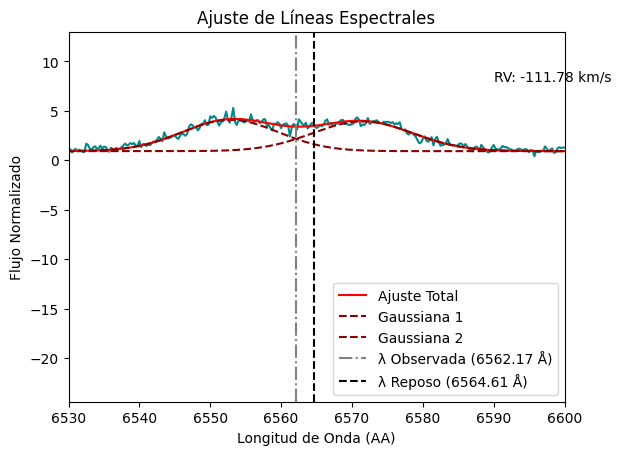

Velocidad Radial estimada: -111.78 km/s


In [ ]:
rv_CT__Hya3= ajuste_RV_Halpha(spec6, bounds=[(3,5),(3,5)], amplitude=[4,4], steddev=5,plot=True)

In [ ]:
rvs_CT_Hya=pd.DataFrame({'RVs_CT_Hya': [rv_CT__Hya1, rv_CT__Hya2, rv_CT__Hya3]})
rvs_CT_Hya['lambda_obs']= [rv_CT__Hya1[1], rv_CT__Hya2[1], rv_CT__Hya3[1]]
rvs_CT_Hya

,RVs_CT_Hya,lambda_obs
0,"(-53.18626181359208, 6563.449370038197)",6563.449370
1,"(-121.20928701768841, 6561.959856570927)",6561.959857
2,"(-111.78381358202596, 6562.16624800347)",6562.166248


In [ ]:
spec4['header']['DATE-OBS']

'2026-03-12T02:38:21.351'

In [ ]:
spec5['header']['DATE-OBS']

'2026-03-12T03:00:20.164'

In [ ]:
spec7['header']['DATE-OBS']

'2026-03-12T03:00:20.164'

### H_beta

C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\69013664.py:13: RuntimeWarning: divide by zero encountered in divide
  weigths= 1/err_64[mask]  #usamos el error para darle más peso a las partes del espectro con mejor SNR


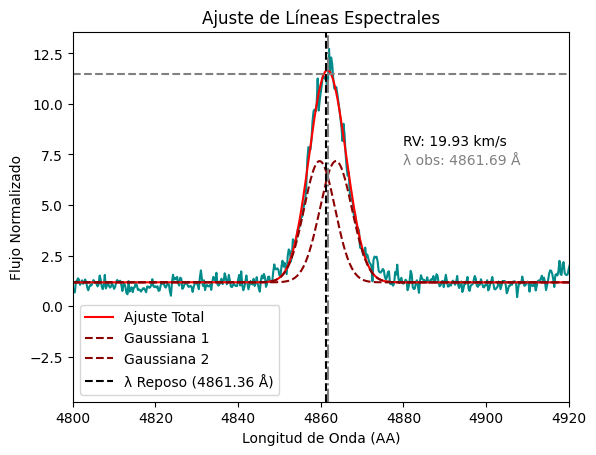

Velocidad Radial estimada: 19.93 km/s


In [ ]:
#Probemos con hbeta
c= const.c.to('km/s').value
h_beta= 4861.363 #medida en el aire

norm= normalize_spectrum(spec0, mask, plot=False)[0]
region_ajuste= SpectralRegion(4800 * u.AA, 4920 * u.AA)   #region de h_beta
    
continuo= models.Const1D(amplitude=1.0) #la parte del continuo
gaussiana1= models.Gaussian1D(amplitude=10, mean=4857.3 * u.AA, stddev=5 * u.AA)
gaussiana2= models.Gaussian1D(amplitude=10, mean=4865.4 * u.AA, stddev=5 * u.AA)


#le damos bounds para que tomen la forma que quiero
gaussiana1.amplitude.bounds= (6,12) 
gaussiana2.amplitude.bounds= (6,12)


modelo_base= continuo + gaussiana1 + gaussiana2
modelo_ajustado= fit_lines(exp0, model= modelo_base, window=region_ajuste)

mu_1= modelo_ajustado[1].mean.value
mu_2= modelo_ajustado[2].mean.value

lambda_obs= (mu_1 + mu_2) / 2
rv= c * (lambda_obs - h_beta) / h_beta


flux_ajustado = modelo_ajustado(exp0.spectral_axis).value
nivel_continuo = modelo_ajustado[0].amplitude.value
campana_1= (modelo_ajustado[1](exp0.spectral_axis) + nivel_continuo).value
campana_2= (modelo_ajustado[2](exp0.spectral_axis) + nivel_continuo).value

plt.plot(spec0['wavelength'], norm0, color='darkcyan')

plt.plot(spec0['wavelength'], flux_ajustado, label='Ajuste Total', color='red')

plt.plot(spec0['wavelength'], campana_1, label='Gaussiana 1', color='darkred', linestyle='--')
plt.plot(spec0['wavelength'], campana_2, label='Gaussiana 2', color='darkred', linestyle='--')
plt.axvline(lambda_obs, color='grey', linestyle='-.')
plt.axvline(h_beta, color='black', linestyle='--', label=f'λ Reposo ({h_beta:.2f} Å)')


plt.xlim(4800, 4920)
plt.xlabel('Longitud de Onda (AA)')
plt.ylabel('Flujo Normalizado')
plt.axhline(11.5, color='grey', linestyle='--')
plt.text(4880,8, f'RV: {rv:.2f} km/s', fontsize=10, color='black')
plt.text(4880,7, f'λ obs: {lambda_obs:.2f} Å', fontsize=10, color='grey')
plt.title('Ajuste de Líneas Espectrales')
plt.legend()
plt.show()
print(f"Velocidad Radial estimada: {rv:.2f} km/s")


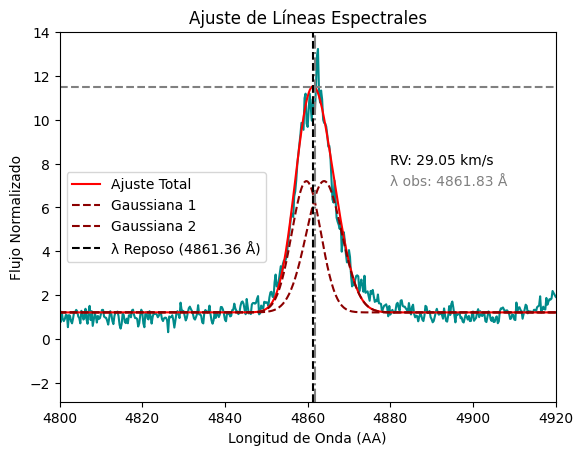

Velocidad Radial estimada: 29.05 km/s


In [ ]:
#Probemos con hbeta
c= const.c.to('km/s').value
h_beta= 4861.363 #medida en el aire

norm= normalize_spectrum(spec1, mask, plot=False)[0]
region_ajuste= SpectralRegion(4800 * u.AA, 4920 * u.AA)   #region de h_beta
    
continuo= models.Const1D(amplitude=1.0) #la parte del continuo
gaussiana1= models.Gaussian1D(amplitude=10, mean=4857.3 * u.AA, stddev=5 * u.AA)
gaussiana2= models.Gaussian1D(amplitude=10, mean=4865.4 * u.AA, stddev=5 * u.AA)


#le damos bounds para que tomen la forma que quiero
gaussiana1.amplitude.bounds= (6,12) 
gaussiana2.amplitude.bounds= (6,12)


modelo_base= continuo + gaussiana1 + gaussiana2
modelo_ajustado= fit_lines(exp1, model= modelo_base, window=region_ajuste)

mu_1= modelo_ajustado[1].mean.value
mu_2= modelo_ajustado[2].mean.value

lambda_obs= (mu_1 + mu_2) / 2
rv= c * (lambda_obs - h_beta) / h_beta


flux_ajustado = modelo_ajustado(exp1.spectral_axis).value
nivel_continuo = modelo_ajustado[0].amplitude.value
campana_1= (modelo_ajustado[1](exp1.spectral_axis) + nivel_continuo).value
campana_2= (modelo_ajustado[2](exp1.spectral_axis) + nivel_continuo).value

plt.plot(spec1['wavelength'], norm, color='darkcyan')

plt.plot(spec1['wavelength'], flux_ajustado, label='Ajuste Total', color='red')

plt.plot(spec1['wavelength'], campana_1, label='Gaussiana 1', color='darkred', linestyle='--')
plt.plot(spec1['wavelength'], campana_2, label='Gaussiana 2', color='darkred', linestyle='--')
plt.axvline(lambda_obs, color='grey', linestyle='-.')
plt.axvline(h_beta, color='black', linestyle='--', label=f'λ Reposo ({h_beta:.2f} Å)')


plt.xlim(4800, 4920)
plt.xlabel('Longitud de Onda (AA)')
plt.ylabel('Flujo Normalizado')
plt.axhline(11.5, color='grey', linestyle='--')
plt.text(4880,8, f'RV: {rv:.2f} km/s', fontsize=10, color='black')
plt.text(4880,7, f'λ obs: {lambda_obs:.2f} Å', fontsize=10, color='grey')
plt.title('Ajuste de Líneas Espectrales')
plt.legend()
plt.show()
print(f"Velocidad Radial estimada: {rv:.2f} km/s")


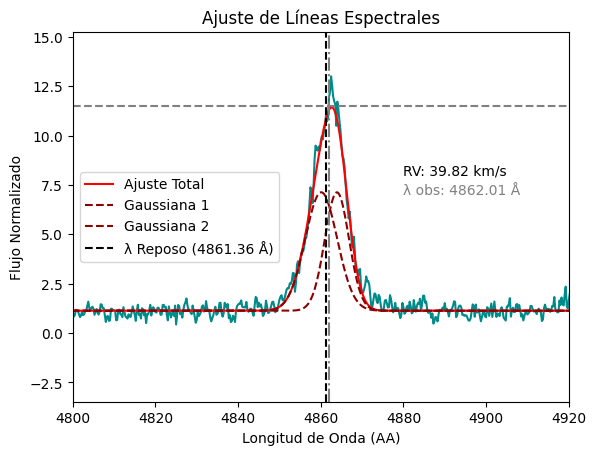

Velocidad Radial estimada: 39.82 km/s


In [ ]:
#Probemos con hbeta
c= const.c.to('km/s').value
h_beta= 4861.363 #medida en el aire

norm= normalize_spectrum(spec2, mask, plot=False)[0]
region_ajuste= SpectralRegion(4800 * u.AA, 4920 * u.AA)   #region de h_beta
    
continuo= models.Const1D(amplitude=1.0) #la parte del continuo
gaussiana1= models.Gaussian1D(amplitude=10, mean=4857.363 * u.AA, stddev=5 * u.AA)
gaussiana2= models.Gaussian1D(amplitude=10, mean=4865.363 * u.AA, stddev=5 * u.AA)


#le damos bounds para que tomen la forma que quiero
gaussiana1.amplitude.bounds= (6,12) 
gaussiana2.amplitude.bounds= (6,12)


modelo_base= continuo + gaussiana1 + gaussiana2
modelo_ajustado= fit_lines(exp2, model= modelo_base, window=region_ajuste)

mu_1= modelo_ajustado[1].mean.value
mu_2= modelo_ajustado[2].mean.value

lambda_obs= (mu_1 + mu_2) / 2
rv= c * (lambda_obs - h_beta) / h_beta


flux_ajustado = modelo_ajustado(exp2.spectral_axis).value
nivel_continuo = modelo_ajustado[0].amplitude.value
campana_1= (modelo_ajustado[1](exp2.spectral_axis) + nivel_continuo).value
campana_2= (modelo_ajustado[2](exp2.spectral_axis) + nivel_continuo).value

plt.plot(spec2['wavelength'], norm, color='darkcyan')

plt.plot(spec2['wavelength'], flux_ajustado, label='Ajuste Total', color='red')

plt.plot(spec2['wavelength'], campana_1, label='Gaussiana 1', color='darkred', linestyle='--')
plt.plot(spec2['wavelength'], campana_2, label='Gaussiana 2', color='darkred', linestyle='--')
plt.axvline(lambda_obs, color='grey', linestyle='-.')
plt.axvline(h_beta, color='black', linestyle='--', label=f'λ Reposo ({h_beta:.2f} Å)')


plt.xlim(4800, 4920)
plt.xlabel('Longitud de Onda (AA)')
plt.ylabel('Flujo Normalizado')
plt.axhline(11.5, color='grey', linestyle='--')
plt.text(4880,8, f'RV: {rv:.2f} km/s', fontsize=10, color='black')
plt.text(4880,7, f'λ obs: {lambda_obs:.2f} Å', fontsize=10, color='grey')
plt.title('Ajuste de Líneas Espectrales')
plt.legend()
plt.show()
print(f"Velocidad Radial estimada: {rv:.2f} km/s")

## EW para qmost_1446

In [ ]:
db_4most= load_all_spectra_4most('CVs2/') #cargamos la carpeta de nuevo (con las nuevas cvs) para no alterar lo de arriba 

Se encontraron 45 archivos espectrales.


C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\3393920557.py:44: RuntimeWarning: invalid value encountered in divide
  snr_red = np.nanmedian(flux[idx_red] /(err[idx_red]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\3393920557.py:47: RuntimeWarning: invalid value encountered in divide
  snr_array= flux/err
C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\3393920557.py:42: RuntimeWarning: invalid value encountered in divide
  snr_blue = np.nanmedian(flux[idx_blue] /(err[idx_blue]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\3393920557.py:43: RuntimeWarning: invalid value encountered in divide
  snr_green = np.nanmedian(flux[idx_green] / (err[idx_green]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\3393920557.py:42: RuntimeWarning: divide by zero encountered in divide
  snr_blue = np.nanmedian(flux[idx_blue] /(err[idx_blue]))
C:\Users\paisa\AppData\Local\Temp\ipykernel_6124\3393920557.py:43: RuntimeWarning: divide by zero encountered in divide
  snr_green = np.nanmedia

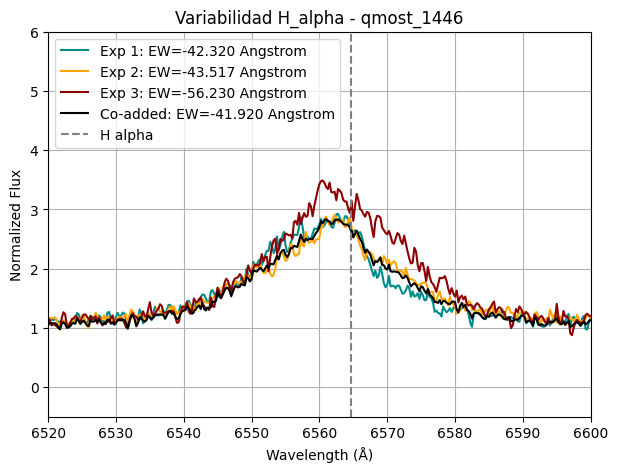

In [ ]:
# calculamos el ew para el sistema qmost_1446 para corroborar variabilidad

qmost_1446_exp1= db_4most[22] #22, 23, 24 y 25 coadded
qmost_1446_exp2= db_4most[23]
qmost_1446_exp3= db_4most[24]
qmost_1446_coadd= db_4most[25]

ew1, norm1= EW(qmost_1446_exp1, line_center=6564.614)
ew2, norm2= EW(qmost_1446_exp2, line_center=6564.614)
ew3, norm3= EW(qmost_1446_exp3, line_center=6564.614)
ew4, norm4= EW(qmost_1446_coadd, line_center=6564.614)


plt.figure(figsize= (7,5))
plt.plot(qmost_1446_exp1['wavelength'], norm1, label=f'Exp 1: EW={ew1:.3f}', color='darkcyan')
plt.plot(qmost_1446_exp2['wavelength'], norm2, label=f'Exp 2: EW={ew2:.3f}', color='orange')
plt.plot(qmost_1446_exp3['wavelength'], norm3, label=f'Exp 3: EW={ew3:.3f}', color='darkred')
plt.plot(qmost_1446_coadd['wavelength'], norm4, label=f'Co-added: EW={ew4:.3f}', color='black')
plt.title('Variabilidad H_alpha - qmost_1446')
plt.axvline(6564.614, color='grey', linestyle='--', label='H alpha')  #línea vertical para marcar la posición de h alpha
plt.xlabel('Wavelength (Å)')
plt.ylabel('Normalized Flux')
plt.xlim(6520,6600)
plt.ylim(-0.5,6)
plt.grid('on')
plt.legend()